# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# EDA (Exploratory Data Analysis)

In [2]:
base_dir='input'
class_labels=os.listdir(base_dir)
class_labels.sort()
print(class_labels)

['Clams', 'Dolphin', 'Jelly Fish', 'Lobster', 'Nudibranchs']


In [3]:
chart_data = []
chart_labels = []

for label in class_labels:
    chart_labels.append(label)
    path = os.path.join(base_dir,label)
    size = len(os.listdir(path))
    chart_data.append(size)
    print(f'Target name: {label:<15} | number of samples in data: {size}')

Target name: Clams           | number of samples in data: 501
Target name: Dolphin         | number of samples in data: 501
Target name: Jelly Fish      | number of samples in data: 501
Target name: Lobster         | number of samples in data: 501
Target name: Nudibranchs     | number of samples in data: 501


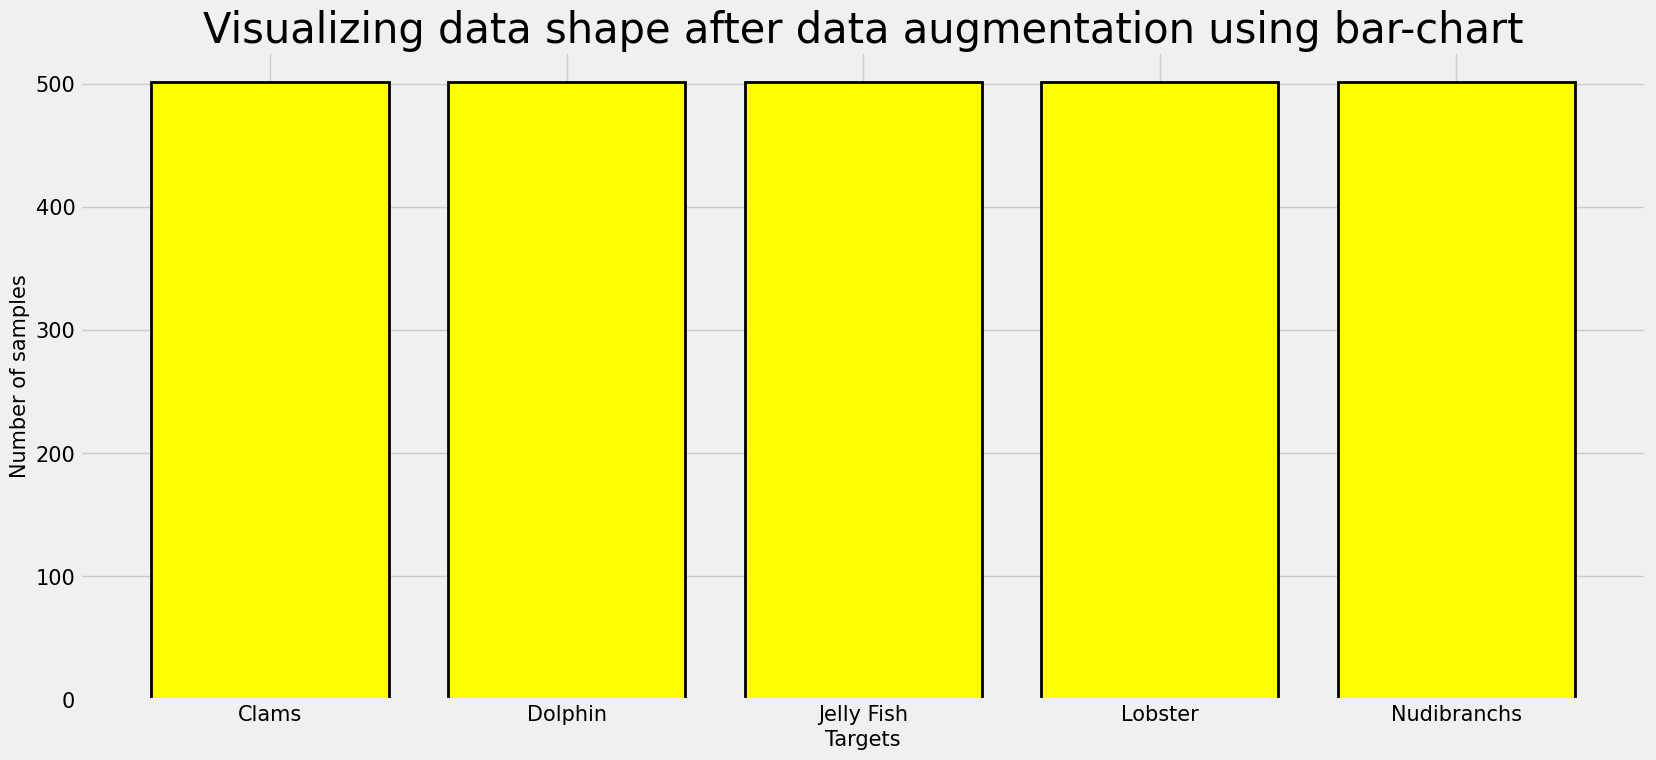

In [4]:
with plt.style.context(style="fivethirtyeight"):
    plt.figure(figsize=(18,8))
    plt.bar(x=chart_labels,
           height=chart_data,
           edgecolor='black',
           linewidth=2,
            color='yellow')
    plt.title(label='Visualizing data shape after data augmentation using bar-chart', fontsize=30)
    plt.xlabel(xlabel='Targets', fontsize=15)
    plt.ylabel(ylabel='Number of samples', fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

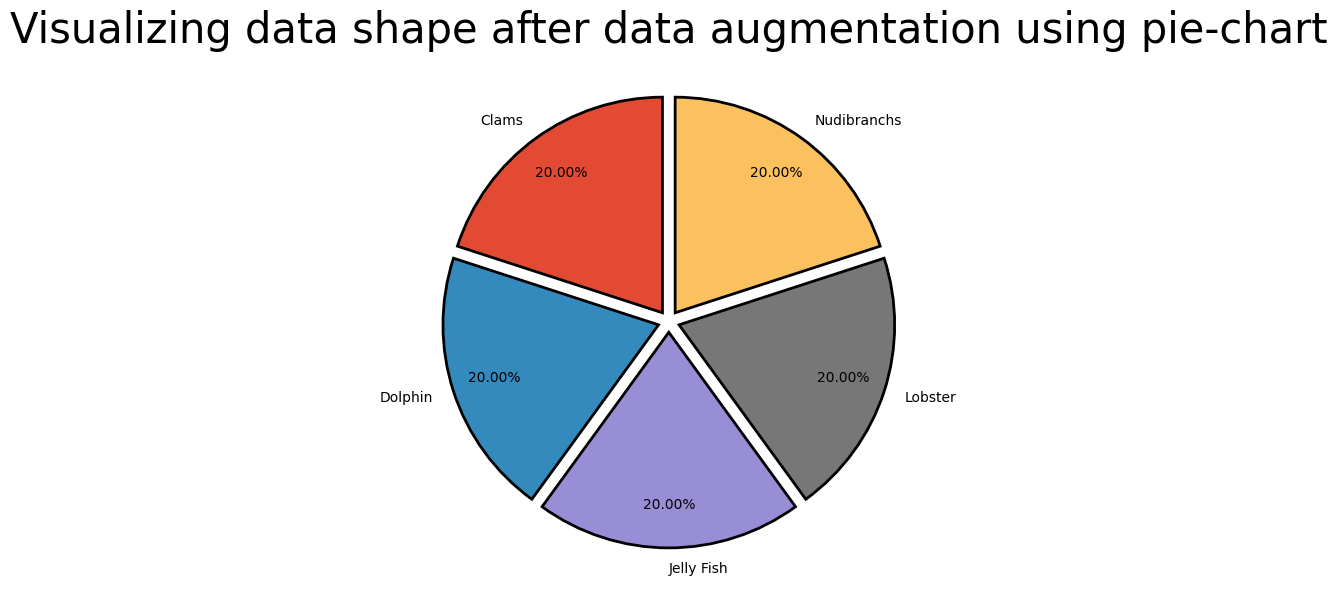

In [5]:
with plt.style.context(style='ggplot'):
    plt.figure(figsize=(7,7))
    plt.pie(labels=chart_labels,
            explode=[0.05]*len(class_labels),
            x=chart_data,
            autopct='%.2f%%',
            startangle=90,
            pctdistance=0.80, wedgeprops={'linewidth':2,'edgecolor':'black'})
    plt.title(label='Visualizing data shape after data augmentation using pie-chart', fontsize=30)
    plt.show()

## Preprocessing 

In [6]:
X = []
y = []
class_name=0
for label in class_labels:
    path=os.path.join(base_dir,label)
    files=os.listdir(path)
    print(f"Loading images from {label} target...")
    for sample in tqdm(files):
        filepath=os.path.join(path,sample)
        try:
            image=cv2.imread(filepath)
            image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
            image=cv2.resize(image,(128,128))
            image=np.array(image)
            image=image/255.0
            X.append(image)
            y.append(class_name)
        except:
            continue
    class_name+=1

Loading images from Clams target...


100%|████████████████████████████████████████████████████████████████████████████████| 501/501 [00:10<00:00, 49.12it/s]


Loading images from Dolphin target...


100%|████████████████████████████████████████████████████████████████████████████████| 501/501 [00:09<00:00, 52.07it/s]


Loading images from Jelly Fish target...


100%|████████████████████████████████████████████████████████████████████████████████| 501/501 [00:10<00:00, 46.39it/s]


Loading images from Lobster target...


100%|████████████████████████████████████████████████████████████████████████████████| 501/501 [00:10<00:00, 46.82it/s]


Loading images from Nudibranchs target...


100%|████████████████████████████████████████████████████████████████████████████████| 501/501 [00:11<00:00, 44.25it/s]


In [7]:
X=np.array(X)
y=np.array(y)

print(X.shape,y.shape)

(2500, 128, 128, 3) (2500,)


In [8]:
X

array([[[[0.17647059, 0.29411765, 0.25882353],
         [0.20784314, 0.34117647, 0.34509804],
         [0.17647059, 0.34509804, 0.36470588],
         ...,
         [0.0745098 , 0.04313725, 0.        ],
         [0.03529412, 0.01568627, 0.        ],
         [0.01568627, 0.        , 0.        ]],

        [[0.23137255, 0.36862745, 0.34117647],
         [0.14117647, 0.28235294, 0.2627451 ],
         [0.28235294, 0.43529412, 0.41960784],
         ...,
         [0.07843137, 0.04313725, 0.        ],
         [0.03921569, 0.01960784, 0.        ],
         [0.01960784, 0.00392157, 0.        ]],

        [[0.25882353, 0.41176471, 0.39215686],
         [0.23529412, 0.37647059, 0.32941176],
         [0.23137255, 0.35686275, 0.29803922],
         ...,
         [0.08235294, 0.04705882, 0.        ],
         [0.04705882, 0.01960784, 0.        ],
         [0.01960784, 0.00392157, 0.        ]],

        ...,

        [[0.40392157, 0.44313725, 0.2       ],
         [0.30196078, 0.36470588, 0.17647059]

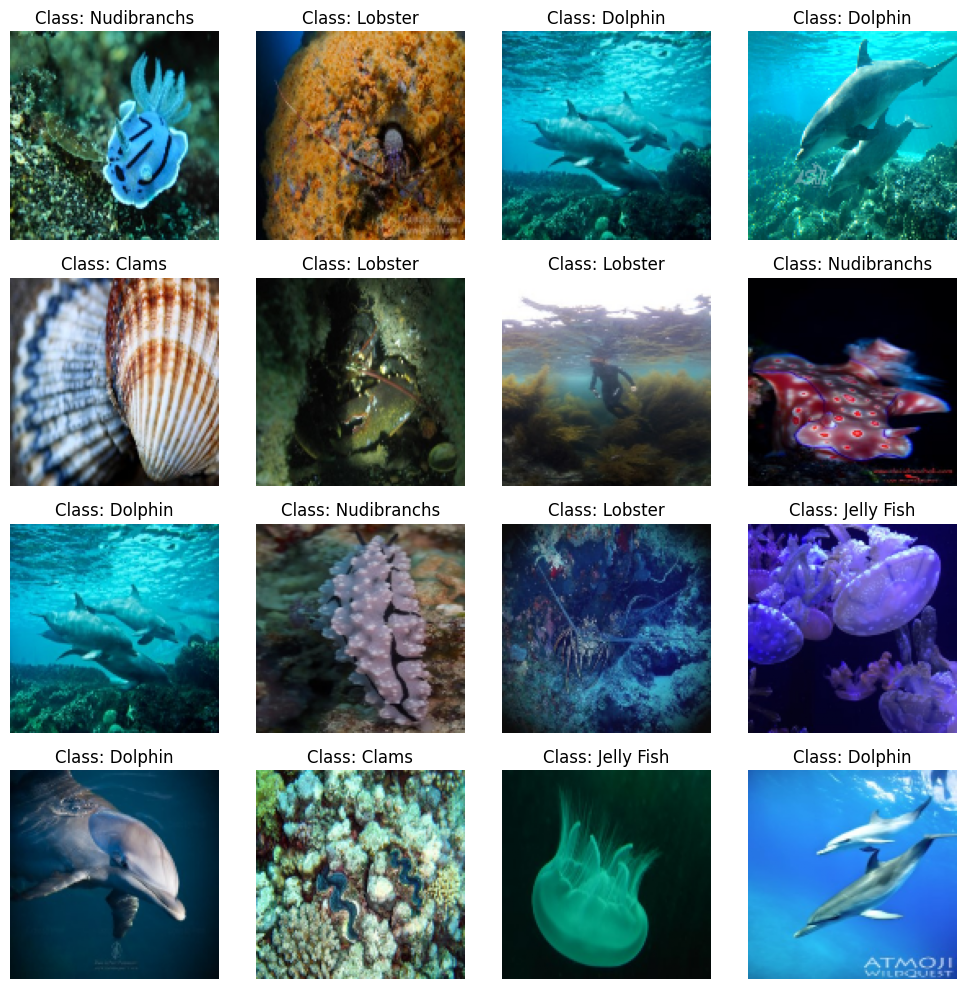

In [9]:
from random import randint

def show_images(images,labels,str_labels):
    plt.figure(figsize=(10,10))
    for i in range(16):
        ax=plt.subplot(4,4,i+1)
        idx=randint(0,len(images)-1)
        plt.imshow(images[idx])
        plt.axis('off')
        plt.title(label=f"Class: {str_labels[labels[idx]]}")
    plt.tight_layout()
    plt.show()
show_images(X,y,class_labels)

# Data Splitting

In [10]:
y=to_categorical(y)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42,stratify=y)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(2000, 128, 128, 3) (500, 128, 128, 3) (2000, 5) (500, 5)


In [11]:
y

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.]], dtype=float32)

# Algorithm: CNN

In [12]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,BatchNormalization,Dense,Dropout,Flatten

In [13]:
cnn_model=Sequential()

cnn_model.add(Conv2D(filters=32,kernel_size=3,strides=(1,1),padding="same",activation="relu",input_shape = (128,128,3)))
cnn_model.add(Conv2D(filters=32,kernel_size=3,strides=(1,1),padding="same",activation="relu"))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPool2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.4))

cnn_model.add(Conv2D(filters=64,kernel_size=3,strides=(1,1),padding="same",activation="relu"))
cnn_model.add(Conv2D(filters=64,kernel_size=3,strides=(1,1),padding="same",activation="relu"))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPool2D(pool_size=(2,2),padding="same"))
cnn_model.add(Dropout(0.4))

cnn_model.add(Conv2D(filters=128,kernel_size=3,strides=(1,1),padding="same",activation="relu"))
cnn_model.add(Conv2D(filters=128,kernel_size=3,strides=(1,1),padding="same",activation="relu"))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPool2D(pool_size=(2,2),padding="same"))
cnn_model.add(Dropout(0.4))

cnn_model.add(Flatten())
cnn_model.add(Dense(units=256,activation="relu"))
cnn_model.add(Dense(units=len(class_labels),activation="softmax"))

In [14]:
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 64, 64, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        1

***Model training***

In [15]:
history = cnn_model.fit(x=X, y=y, batch_size=64, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
40/40 [==============================] - 202s 5s/step - loss: 5.5169 - accuracy: 0.5112 - val_loss: 12.8522 - val_accuracy: 0.2000
Epoch 2/20
40/40 [==============================] - 200s 5s/step - loss: 1.0216 - accuracy: 0.6264 - val_loss: 12.3066 - val_accuracy: 0.2220
Epoch 3/20
40/40 [==============================] - 184s 5s/step - loss: 1.0751 - accuracy: 0.6468 - val_loss: 5.7359 - val_accuracy: 0.2560
Epoch 4/20
40/40 [==============================] - 337s 9s/step - loss: 0.9410 - accuracy: 0.6432 - val_loss: 2.5763 - val_accuracy: 0.2140
Epoch 5/20
40/40 [==============================] - 197s 5s/step - loss: 0.7730 - accuracy: 0.7112 - val_loss: 2.9518 - val_accuracy: 0.2460
Epoch 6/20
40/40 [==============================] - 95s 2s/step - loss: 1.0018 - accuracy: 0.6316 - val_loss: 7.6482 - val_accuracy: 0.2740
Epoch 7/20
40/40 [==============================] - 94s 2s/step - loss: 0.7703 - accuracy: 0.7096 - val_loss: 8.9686 - val_accuracy: 0.2660
Epoch 8/20
40

***Accuracy and Loss plot-graphs***

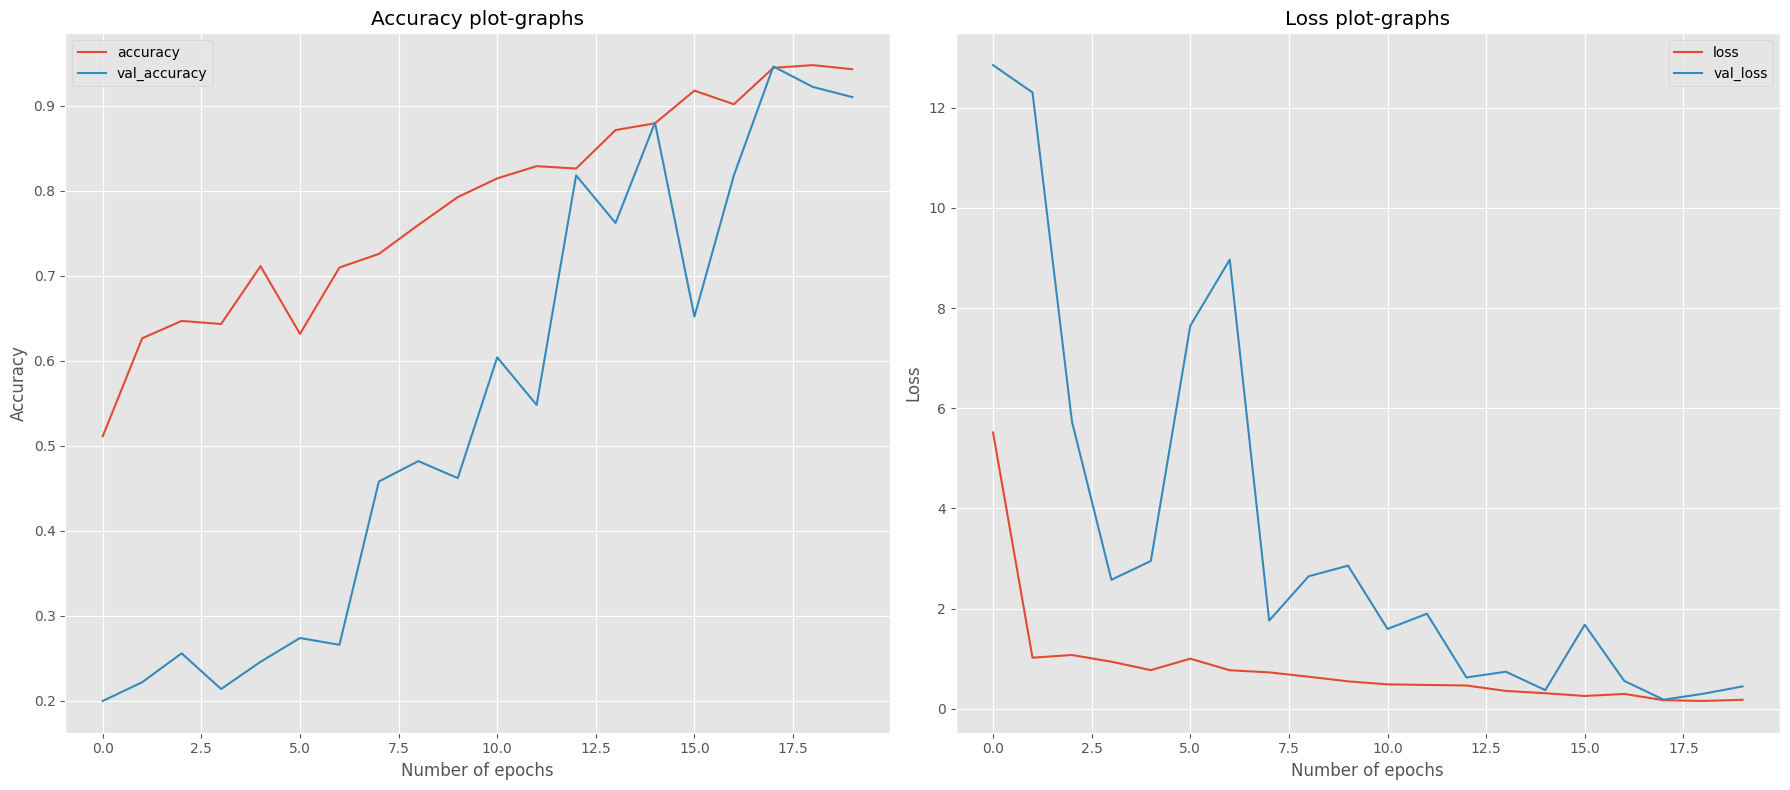

In [16]:
with plt.style.context(style='ggplot'):
    fig,axes=plt.subplots(nrows=1,ncols=2,figsize=(18,8))
    axes[0].plot(history.history["accuracy"],label="accuracy")
    axes[0].plot(history.history["val_accuracy"],label="val_accuracy")
    axes[0].set_title(label='Accuracy plot-graphs')
    axes[0].set_xlabel(xlabel='Number of epochs')
    axes[0].set_ylabel(ylabel='Accuracy')
    axes[0].legend()
    axes[1].plot(history.history["loss"],label="loss")
    axes[1].plot(history.history["val_loss"],label="val_loss")
    axes[1].set_title(label='Loss plot-graphs')
    axes[1].set_xlabel(xlabel='Number of epochs')
    axes[1].set_ylabel(ylabel='Loss')
    axes[1].legend()
    fig.tight_layout()
    plt.show()

In [17]:
model_prediction=cnn_model.predict(X_test,batch_size=32,verbose=1)

16/16 [==============================] - 6s 312ms/step


In [18]:
print(model_prediction)

[[9.97298777e-01 1.77304784e-08 3.07259171e-07 2.85959977e-04
  2.41492270e-03]
 [1.18658945e-05 5.10999374e-03 9.93695557e-01 1.25726392e-05
  1.17002171e-03]
 [8.79723288e-04 9.79277194e-01 9.81928315e-03 9.85296909e-03
  1.70808984e-04]
 ...
 [3.23683817e-05 5.71166947e-10 2.21607211e-13 9.99943614e-01
  2.39096189e-05]
 [2.35494772e-05 8.95214736e-01 2.01118784e-03 3.38350749e-03
  9.93669480e-02]
 [9.66113566e-06 2.20861388e-04 9.99480546e-01 5.63378080e-06
  2.83369416e-04]]


In [19]:
pred = np.argmax(model_prediction,axis=1)
actual = np.argmax(y_test,axis=1)

In [20]:
print(pred.tolist())

[0, 2, 1, 2, 2, 0, 2, 3, 0, 0, 1, 2, 3, 4, 1, 4, 3, 4, 3, 0, 2, 2, 0, 2, 1, 2, 3, 1, 4, 0, 2, 4, 3, 0, 1, 2, 0, 0, 2, 3, 2, 1, 1, 4, 4, 1, 3, 2, 2, 3, 4, 1, 1, 1, 2, 2, 4, 0, 3, 0, 4, 2, 3, 4, 4, 4, 3, 4, 2, 2, 3, 0, 1, 4, 2, 4, 1, 1, 4, 3, 1, 3, 4, 2, 1, 2, 0, 4, 1, 4, 4, 0, 0, 0, 2, 2, 2, 4, 0, 2, 2, 4, 4, 2, 0, 3, 3, 0, 2, 0, 0, 0, 3, 1, 0, 3, 0, 0, 4, 4, 1, 2, 0, 4, 3, 3, 3, 4, 4, 4, 2, 4, 3, 1, 4, 3, 1, 4, 4, 3, 4, 1, 4, 0, 1, 4, 4, 0, 3, 1, 2, 0, 4, 2, 1, 3, 2, 4, 4, 3, 2, 2, 4, 0, 4, 4, 3, 1, 0, 0, 3, 1, 0, 2, 3, 0, 3, 1, 4, 2, 1, 0, 0, 1, 0, 3, 4, 4, 3, 2, 3, 1, 1, 0, 0, 2, 0, 2, 1, 4, 4, 4, 1, 4, 3, 2, 1, 3, 0, 0, 4, 4, 0, 3, 2, 1, 3, 0, 3, 1, 2, 0, 4, 0, 1, 2, 0, 3, 3, 2, 2, 0, 1, 1, 2, 1, 2, 3, 2, 3, 0, 0, 1, 3, 0, 2, 0, 0, 2, 3, 3, 0, 1, 1, 2, 3, 1, 4, 0, 1, 4, 3, 1, 4, 4, 2, 4, 0, 2, 0, 4, 2, 4, 1, 4, 3, 4, 3, 2, 0, 1, 2, 0, 4, 3, 2, 3, 1, 3, 2, 4, 4, 3, 0, 2, 0, 1, 3, 2, 0, 4, 1, 3, 4, 3, 1, 3, 1, 3, 4, 3, 2, 2, 4, 3, 0, 4, 2, 3, 1, 3, 1, 0, 4, 1, 1, 1, 2, 4, 4, 2, 3, 0, 

In [21]:
print(actual.tolist())

[0, 2, 1, 2, 2, 0, 2, 3, 0, 0, 1, 2, 3, 4, 2, 0, 3, 4, 3, 0, 2, 2, 0, 2, 1, 0, 3, 1, 4, 0, 2, 0, 3, 0, 1, 2, 0, 0, 2, 3, 2, 1, 1, 4, 4, 1, 3, 2, 2, 3, 4, 1, 1, 1, 2, 2, 4, 0, 3, 1, 4, 2, 3, 4, 4, 4, 2, 4, 2, 2, 1, 0, 1, 4, 2, 0, 1, 1, 4, 3, 1, 3, 4, 2, 1, 2, 0, 4, 1, 0, 4, 0, 0, 0, 2, 2, 2, 0, 0, 2, 2, 4, 4, 2, 0, 1, 3, 0, 2, 0, 0, 0, 3, 1, 0, 3, 0, 0, 4, 4, 1, 2, 0, 4, 3, 3, 3, 4, 4, 4, 2, 4, 3, 1, 4, 3, 1, 4, 2, 3, 0, 1, 1, 0, 1, 4, 4, 0, 3, 1, 2, 0, 4, 2, 1, 3, 2, 0, 4, 3, 2, 2, 4, 0, 0, 4, 3, 1, 0, 0, 3, 1, 0, 2, 3, 0, 3, 1, 3, 2, 1, 0, 0, 1, 0, 3, 4, 4, 4, 2, 2, 1, 1, 0, 0, 2, 0, 2, 1, 4, 4, 4, 1, 4, 3, 2, 1, 3, 0, 0, 4, 4, 0, 3, 2, 1, 3, 0, 3, 1, 2, 0, 4, 0, 1, 2, 0, 4, 3, 2, 2, 4, 1, 1, 2, 1, 2, 2, 1, 3, 0, 0, 1, 3, 0, 2, 0, 0, 2, 3, 3, 0, 1, 0, 2, 3, 1, 4, 0, 1, 4, 3, 1, 4, 4, 2, 0, 0, 2, 0, 0, 2, 4, 1, 4, 3, 4, 3, 2, 0, 1, 2, 0, 4, 3, 2, 3, 1, 3, 2, 4, 4, 3, 0, 2, 0, 1, 3, 2, 0, 4, 1, 3, 4, 3, 1, 3, 1, 3, 4, 0, 2, 2, 4, 3, 0, 4, 2, 3, 1, 3, 1, 0, 4, 1, 1, 1, 2, 4, 4, 2, 3, 0, 

### Result Analysis

***Accuracy Score***

In [22]:
accuracy=accuracy_score(y_true=actual,y_pred=pred)
print(f"Validation accuracy of ConvolutionalNeuralNetwork model is {accuracy*100.0:.2f}%")

Validation accuracy of ConvolutionalNeuralNetwork model is 91.00%


***Classification Report***

In [23]:
print(classification_report(y_true=actual,y_pred=pred,target_names=class_labels))

              precision    recall  f1-score   support

       Clams       0.97      0.85      0.90       100
     Dolphin       0.97      0.87      0.92       100
  Jelly Fish       0.97      0.93      0.95       100
     Lobster       0.85      0.97      0.91       100
 Nudibranchs       0.83      0.93      0.88       100

    accuracy                           0.91       500
   macro avg       0.92      0.91      0.91       500
weighted avg       0.92      0.91      0.91       500



***Confusion Matrix***

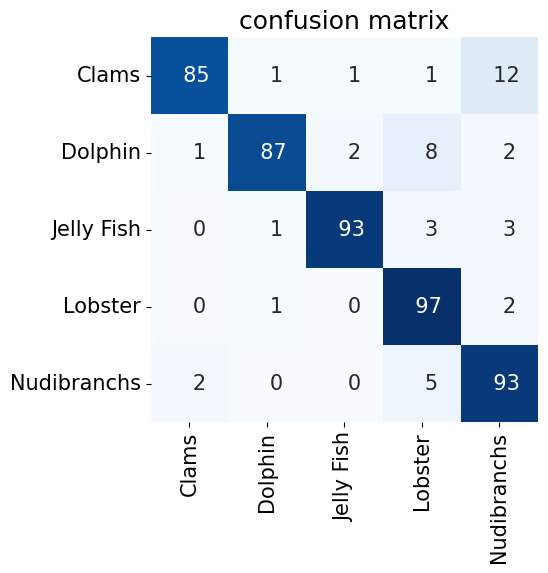

In [24]:
plt.figure(figsize=(5,5))
plt.rcParams['font.size']=15
ax=sns.heatmap(data=confusion_matrix(y_true=actual,y_pred=pred),
               annot=True,
               fmt='4d',
               cbar=False,
               xticklabels=class_labels,
               yticklabels=class_labels,
               cmap=plt.cm.Blues)
plt.title(label='confusion matrix')
plt.show()

***model saving***

In [25]:
cnn_model.save("models/ConvolutionalNeuralNetwork_model.h5")

---